In [12]:
import glob

import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import xarray as xr
import numpy as np

from unseen import fileio
import spatial

In [13]:
mask = spatial.get_mask()

In [15]:
def get_model_data(metric, model):
    """Get grid point data for a single metric/model combination"""

    var = {'txx': 'tasmax', 'rx1day': 'pr'}
    model_file = glob.glob(f'/g/data/xv83/unseen-projects/outputs/bias/data/independence-{metric}_{model}-*_*_annual-jul-to-jun_AUS300i.nc')[0]
    ds = fileio.open_dataset(model_file)

    return ds['min_lead'].where(mask)

In [ ]:
models = [
    'BCC-CSM2-MR'
    'CAFE',
    'CMCC-CM2-SR5',
    'CanESM5',
    'EC-Earth3',
    'IPSL-CM6A-LR',
    'MIROC6',
    'MPI-ESM1-2-HR',
    'MRI-ESM2-0',
    'NorCPM1',
]

In [22]:
da = get_model_data('txx', 'CanESM5')
da_mean = float(da.mean())
print(f'mean: {da_mean:.1f}')

mean: 2.2


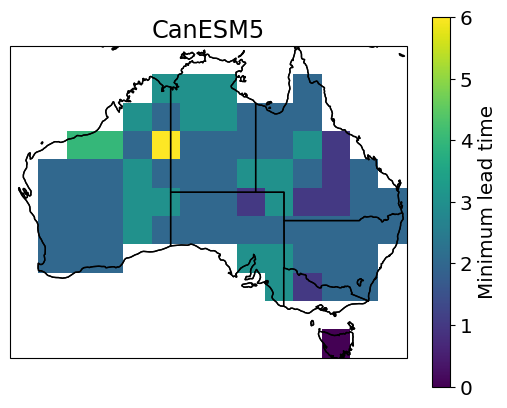

In [17]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())
im1 = da.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
#    cbar_kwargs={'label': 'variance (rx1day, $mm^2$)'},
#    levels=np.arange(0, 5000, 500),
#    cmap=cmocean.cm.rain,
)
ax1.set_title('CanESM5')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

plt.show()